In [32]:
from pyrtid.inverse.regularization.aca import GenerateDenseMatrix, ACApp
from scipy.linalg import svdvals as svd
import numpy as np
from time import time
import logging
import matplotlib.pyplot as plt

logger = logging.getLogger()
logger.setLevel(logging.INFO)

# Test for ACA
N = 1000
# pts = np.linspace(0,1,N)[:,np.newaxis]
pts = np.random.rand(N, 2)
pts[int(N / 2) :, 0] += 2.0
pts[int(N / 2) :, 1] += 2.0

indx = np.arange(N / 2, dtype=np.int32)
indy = np.setdiff1d(np.arange(N), indx).astype(np.int32)


# Kernel
def kernel(R):
    return np.exp(-R)


rkmax = int(N / 2)
eps = 1.0e-12
logging.info(f"rkmax={rkmax}, eps = {eps}")

start = time()
mat = GenerateDenseMatrix(pts, indx, indy, kernel)
logging.info(f"Time for full construction is {(time() - start)}")

start = time()
A, B = ACApp(pts, indx, indy, kernel, rkmax, eps)
logging.info("Time for ACA construction is %g" % (time() - start))

s = svd(mat)
s = s / s[0]
ind = np.extract(s > 1.0e-6, s)

logging.info(
    f"Error is {np.linalg.norm(mat - np.dot(A, B.transpose())) / np.linalg.norm(mat)}"
)
logging.info(f"size(A) = {np.size(A, 1)}, ind.size = {ind.size}")

INFO:root:rkmax=500, eps = 1e-12
INFO:root:Time for full construction is 0.020145177841186523
INFO:root:Time for ACA construction is 0.0278733
INFO:root:Error is 8.218830606572054e-08
INFO:root:size(A) = 17, ind.size = 9


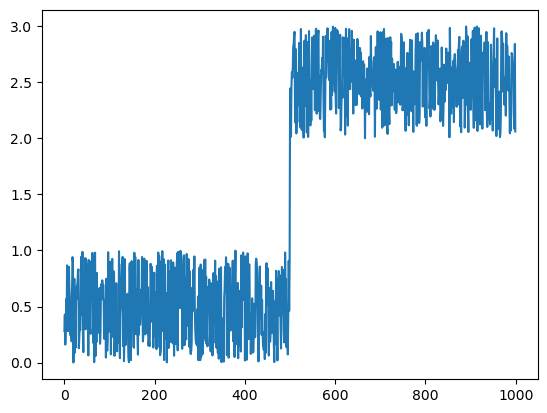

In [16]:
plt.plot(pts[:, 0])

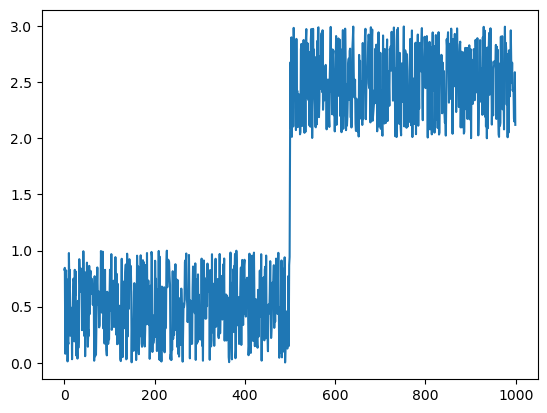

In [17]:
plt.plot(pts[:, 1])

In [18]:
mat.shape

(500, 500)

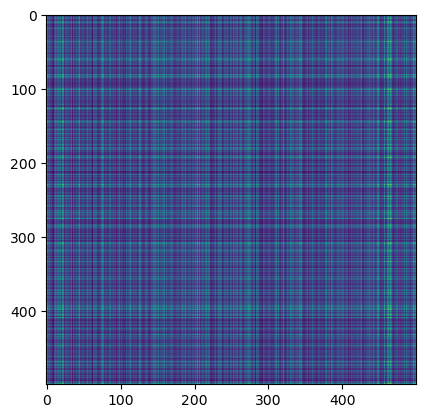

In [19]:
plt.imshow(mat)

In [20]:
indx

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

In [21]:
indy

array([500, 501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511, 512,
       513, 514, 515, 516, 517, 518, 519, 520, 521, 522, 523, 524, 525,
       526, 527, 528, 529, 530, 531, 532, 533, 534, 535, 536, 537, 538,
       539, 540, 541, 542, 543, 544, 545, 546, 547, 548, 549, 550, 551,
       552, 553, 554, 555, 556, 557, 558, 559, 560, 561, 562, 563, 564,
       565, 566, 567, 568, 569, 570, 571, 572, 573, 574, 575, 576, 577,
       578, 579, 580, 581, 582, 583, 584, 585, 586, 587, 588, 589, 590,
       591, 592, 593, 594, 595, 596, 597, 598, 599, 600, 601, 602, 603,
       604, 605, 606, 607, 608, 609, 610, 611, 612, 613, 614, 615, 616,
       617, 618, 619, 620, 621, 622, 623, 624, 625, 626, 627, 628, 629,
       630, 631, 632, 633, 634, 635, 636, 637, 638, 639, 640, 641, 642,
       643, 644, 645, 646, 647, 648, 649, 650, 651, 652, 653, 654, 655,
       656, 657, 658, 659, 660, 661, 662, 663, 664, 665, 666, 667, 668,
       669, 670, 671, 672, 673, 674, 675, 676, 677, 678, 679, 68

In [22]:
pts.size

2000